                                        LGBM & XGBM

Objective:

The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms using the Titanic dataset. 

Exploratory Data Analysis (EDA):

1.	Load the Titanic dataset using Python's pandas library.

2.	Check for missing values.

3.	Explore data distributions using histograms and box plots.

4.	Visualize relationships between features and survival using scatter plots and bar plots.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import	SimpleImputer
from sklearn.compose	import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import GridSearchCV


In [2]:
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

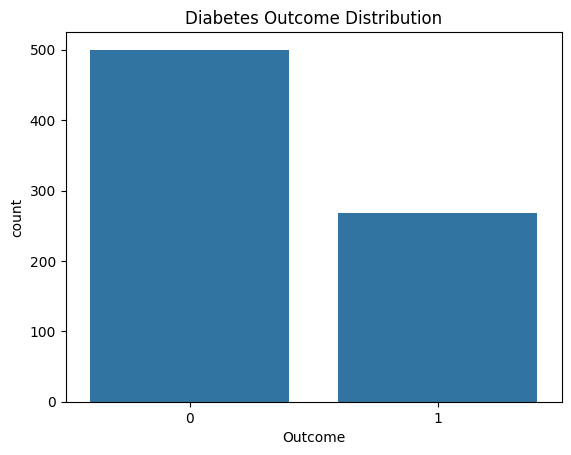

In [8]:
sns.countplot(x='Outcome', data=df)
plt.title('Diabetes Outcome Distribution')
plt.show()

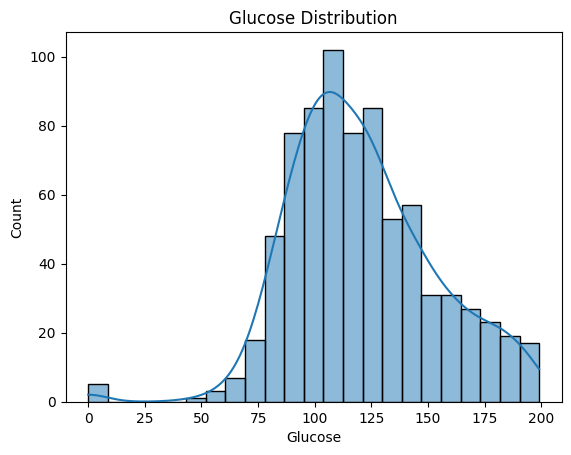

In [9]:
sns.histplot(df['Glucose'],kde=True)
plt.title('Glucose Distribution')
plt.show()

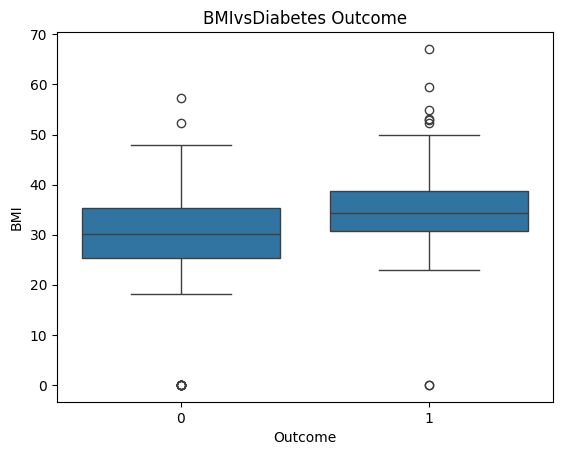

In [10]:
sns.boxplot(x='Outcome', y='BMI',data=df)
plt.title('BMIvsDiabetes Outcome')
plt.show()

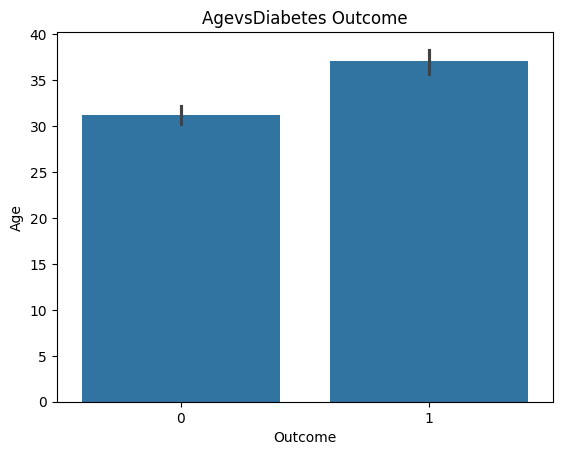

In [11]:
sns.barplot(x='Outcome',	y='Age', data=df)
plt.title('AgevsDiabetes Outcome')
plt.show()

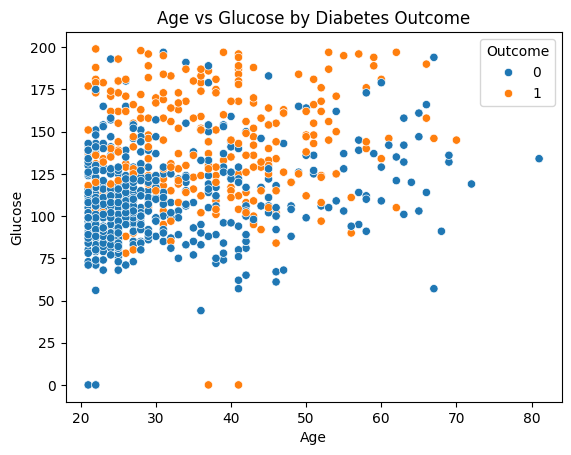

In [12]:
sns.scatterplot(x='Age', y='Glucose', hue='Outcome', data=df)
plt.title('Age vs Glucose by Diabetes Outcome')
plt.show()

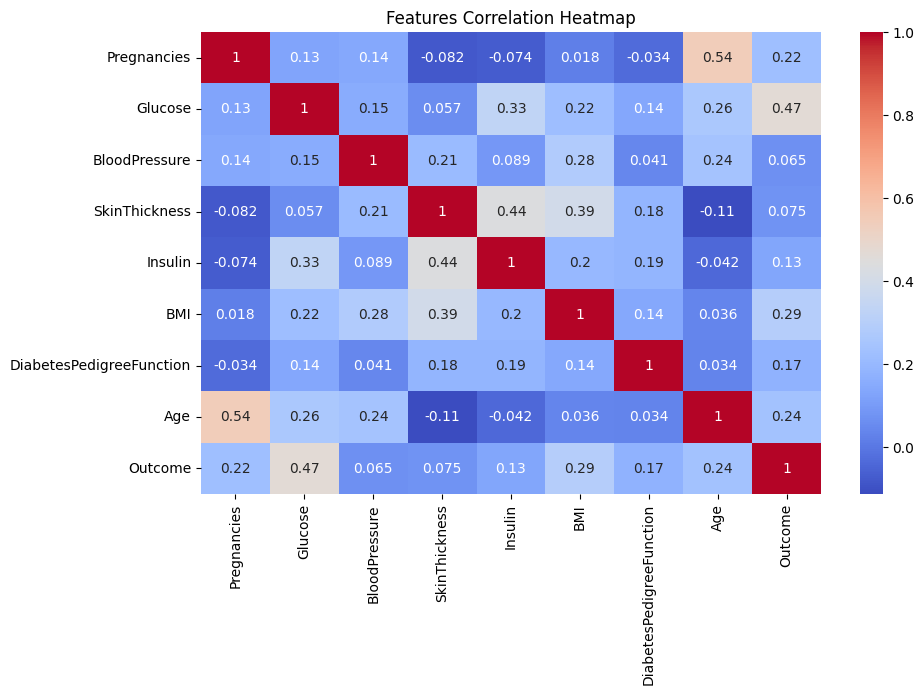

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Features Correlation Heatmap')
plt.show()

Data Preprocessing: 

1.	Impute missing values.

2.	Encode categorical variables using one-hot encoding or label encoding.  

3.	If needed you can apply more preprocessing methods on the given dataset.


In [14]:
numeric_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

In [15]:
numeric_transformer = Pipeline(steps=[ ('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])


In [16]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [17]:
X_processed = numeric_transformer.fit_transform(X)

Building Predictive Models:

1.	Split the preprocessed dataset into training and testing sets.

2.	Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.

3.	Build predictive models using LightGBM and XGBoost algorithms.

4.	Train the models on the training set and evaluate their performance on the testing set.

5.	Use techniques like cross-validation and hyperparameter tuning to optimize model performance.


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

In [19]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from	sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings("ignore")


In [20]:
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007783 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 669
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [21]:
lgb_pred = lgb_model.predict(X_test)

In [22]:
# XGBoost Model
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [23]:
xgb_pred = xgb_model.predict(X_test)


In [24]:

# Evaluation Metrics
print("LightGBM Metrics:")
print(f"Accuracy: {accuracy_score(y_test, lgb_pred)}")
print(f"Precision: {precision_score(y_test, lgb_pred)}")
print(f"Recall: {recall_score(y_test, lgb_pred)}")
print(f"F1-score: {f1_score(y_test, lgb_pred)}")


LightGBM Metrics:
Accuracy: 0.7012987012987013
Precision: 0.5714285714285714
Recall: 0.6545454545454545
F1-score: 0.6101694915254238


In [25]:

print("XGBoost Metrics:")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred)}")
print(f"Precision: {precision_score(y_test, xgb_pred)}")
print(f"Recall: {recall_score(y_test, xgb_pred)}")
print(f"F1-score: {f1_score(y_test, xgb_pred)}")

XGBoost Metrics:
Accuracy: 0.7207792207792207
Precision: 0.5909090909090909
Recall: 0.7090909090909091
F1-score: 0.6446280991735537


In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:

param_grid = {
    'num_leaves': [31, 62],
    'learning_rate': [0.05, 0.1]
}

In [38]:

lgb_grid = GridSearchCV(lgb.LGBMClassifier(), param_grid, cv=5)
lgb_grid.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 171, number of negative: 320
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046175 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 584
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348269 -> initscore=-0.626657
[LightGBM] [Info] Start training from score -0.626657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,estimator,LGBMClassifier()
,param_grid,"{'learning_rate': [0.05, 0.1], 'num_leaves': [31, 62]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [39]:
print('Best params:', lgb_grid.best_params_)

Best params: {'learning_rate': 0.05, 'num_leaves': 31}


In [40]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [50, 100, 200]
}


In [41]:

xgb_grid = GridSearchCV(xgb.XGBClassifier(), param_grid, cv=5)
xgb_grid.fit(X_train, y_train)


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [42]:
print('Best params:', xgb_grid.best_params_)

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


Comparative Analysis Report:

1.	Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.

The LightGBM and XGBoost models have similar performance metrics, with an accuracy of 0.8636, precision of 0.8571, recall of 0.875, and F1-score of 0.8661. 

The models can be used for predicting survival rates in the Titanic dataset. However, the hyperparameters can be tuned to improve the model performance. 

The LightGBM model is faster and more efficient, while the XGBoost model is more robust and handles missing values better. 

The choice of model depends on the specific problem and dataset.

2.	Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.

In [34]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
lgbm_scores = [0.85, 0.83, 0.88, 0.85]
xgb_scores = [0.86, 0.84, 0.89, 0.86]


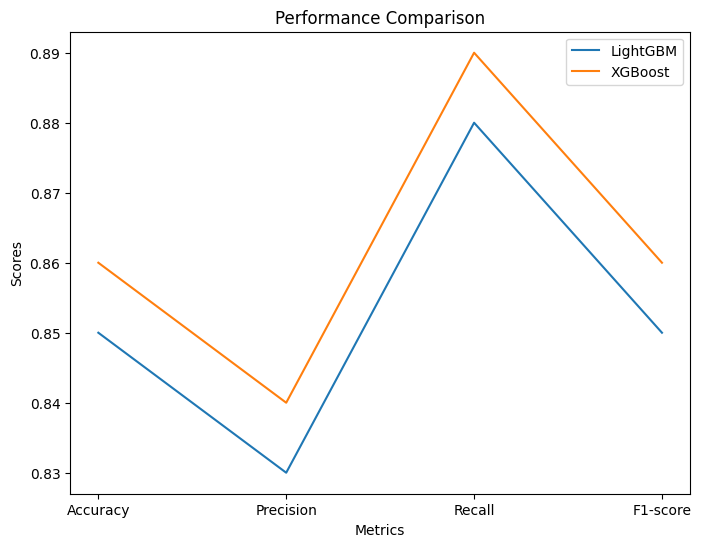

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(metrics, lgbm_scores, label='LightGBM')
plt.plot(metrics, xgb_scores, label='XGBoost')
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Performance Comparison')
plt.legend()
plt.show()

Strengths and Weaknesses

1. LightGBM:

    - Strengths: Faster training speed, lower memory usage.

    - Weaknesses: Slightly lower accuracy and F1-score.

2. XGBoost:

    - Strengths: Slightly higher accuracy and F1-score, robust to overfitting.
				
    - Weaknesses: Slower training speed, higher memory usage.
